In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

In [9]:
usuarios_activos = pd.read_csv('drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_activos_actualizado.csv')
usuarios_eliminados = pd.read_csv('drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_eliminados_actualizado.csv')

In [10]:
usuarios_activos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29522 entries, 0 to 29521
Data columns (total 39 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   id                                       29522 non-null  int64  
 1   amount                                   29522 non-null  float64
 2   status                                   29522 non-null  object 
 3   created_at                               29522 non-null  object 
 4   updated_at                               29522 non-null  object 
 5   user_id                                  29522 non-null  float64
 6   moderated_at                             19434 non-null  object 
 7   reimbursement_date                       29522 non-null  object 
 8   cash_request_received_date               22988 non-null  object 
 9   money_back_date                          22750 non-null  object 
 10  transfer_type                            29522

In [11]:
usuarios_eliminados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2573 entries, 0 to 2572
Data columns (total 39 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   id                                       2573 non-null   int64  
 1   amount                                   2573 non-null   float64
 2   status                                   2573 non-null   object 
 3   created_at                               2573 non-null   object 
 4   updated_at                               2573 non-null   object 
 5   moderated_at                             2326 non-null   object 
 6   deleted_account_id                       2573 non-null   float64
 7   reimbursement_date                       2573 non-null   object 
 8   cash_request_received_date               1162 non-null   object 
 9   money_back_date                          1168 non-null   object 
 10  transfer_type                            2573 no

In [7]:
usuarios_activos["created_at"].min()

Timestamp('2019-11-19 13:57:53.511561')

In [12]:
import pandas as pd

# Lista de columnas de fechas en los datasets
columnas_fechas = [
    "created_at", "updated_at", "paid_at", "from_date", "to_date",
    "created_at_fees", "updated_at_fees", "paid_at_fees",
    "cash_request_created_at", "cash_request_updated_at",
    "reimbursement_date", "cash_request_received_date",
    "money_back_date", "send_at", "moderated_at"
]

# Función para convertir fechas eliminando la zona horaria
def convertir_fechas_sin_zona_horaria(df, columnas_fechas):
    for col in columnas_fechas:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce").dt.tz_localize(None)
    return df

# Aplicar la conversión a ambos datasets
usuarios_activos = convertir_fechas_sin_zona_horaria(usuarios_activos, columnas_fechas)
usuarios_eliminados = convertir_fechas_sin_zona_horaria(usuarios_eliminados, columnas_fechas)




In [14]:
usuarios_activos["cohorte_primer_solicitud"] = usuarios_activos.groupby("user_id")["created_at"].transform("min").dt.to_period("M")
usuarios_eliminados["cohorte_primer_solicitud"] = usuarios_eliminados.groupby("deleted_account_id")["created_at"].transform("min").dt.to_period("M")

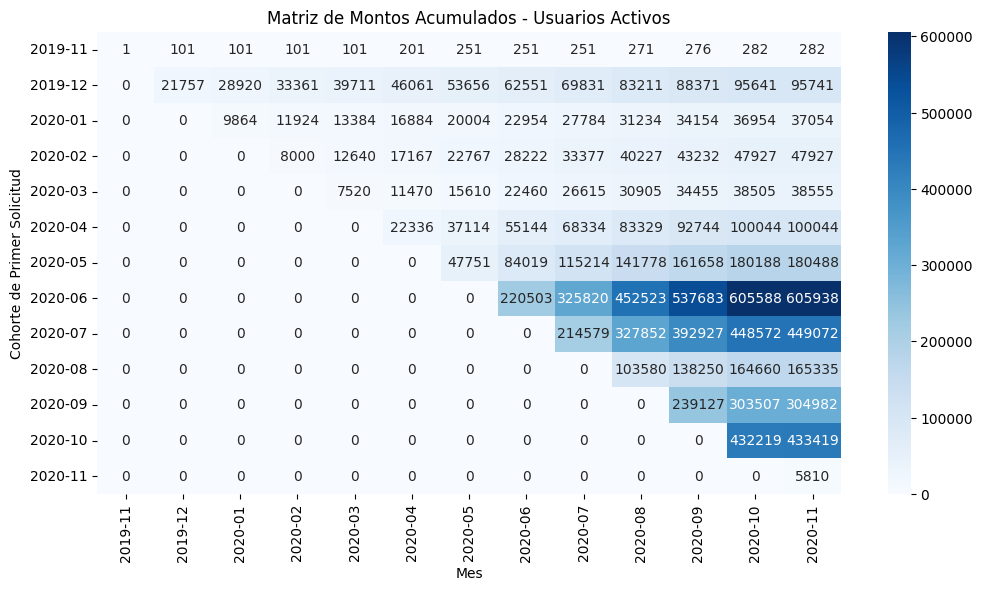

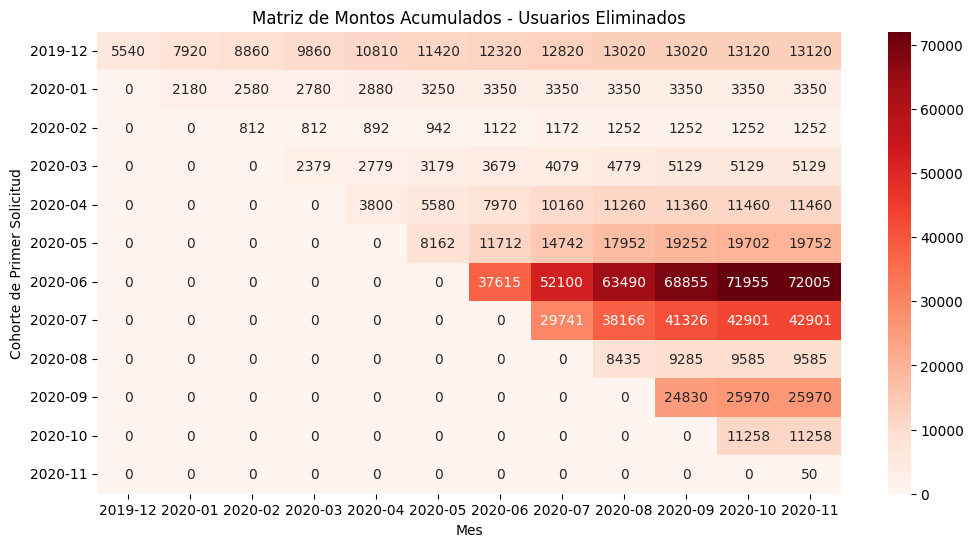

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Convertir la columna de fecha a datetime
usuarios_activos["created_at"] = pd.to_datetime(usuarios_activos["created_at"], errors="coerce")
usuarios_eliminados["created_at"] = pd.to_datetime(usuarios_eliminados["created_at"], errors="coerce")

# Asegurar que la columna de Mes esté en formato período (Año-Mes)
usuarios_activos["Mes"] = usuarios_activos["created_at"].dt.to_period("M")
usuarios_eliminados["Mes"] = usuarios_eliminados["created_at"].dt.to_period("M")

# Crear la matriz de montos acumulados por cohorte y mes (Usuarios Activos)
cohorte_matriz_activos = usuarios_activos.pivot_table(
    index="cohorte_primer_solicitud",
    columns="Mes",
    values="amount",
    aggfunc="sum",
    fill_value=0
).cumsum(axis=1)

# Crear la matriz de montos acumulados por cohorte y mes (Usuarios Eliminados)
cohorte_matriz_eliminados = usuarios_eliminados.pivot_table(
    index="cohorte_primer_solicitud",
    columns="Mes",
    values="amount",
    aggfunc="sum",
    fill_value=0
).cumsum(axis=1)

# Visualización de la matriz de cohorte (Usuarios Activos)
plt.figure(figsize=(12, 6))
sns.heatmap(cohorte_matriz_activos, cmap="Blues", annot=True, fmt=".0f")
plt.title("Matriz de Montos Acumulados - Usuarios Activos")
plt.xlabel("Mes")
plt.ylabel("Cohorte de Primer Solicitud")
plt.show()

# Visualización de la matriz de cohorte (Usuarios Eliminados)
plt.figure(figsize=(12, 6))
sns.heatmap(cohorte_matriz_eliminados, cmap="Reds", annot=True, fmt=".0f")
plt.title("Matriz de Montos Acumulados - Usuarios Eliminados")
plt.xlabel("Mes")
plt.ylabel("Cohorte de Primer Solicitud")
plt.show()



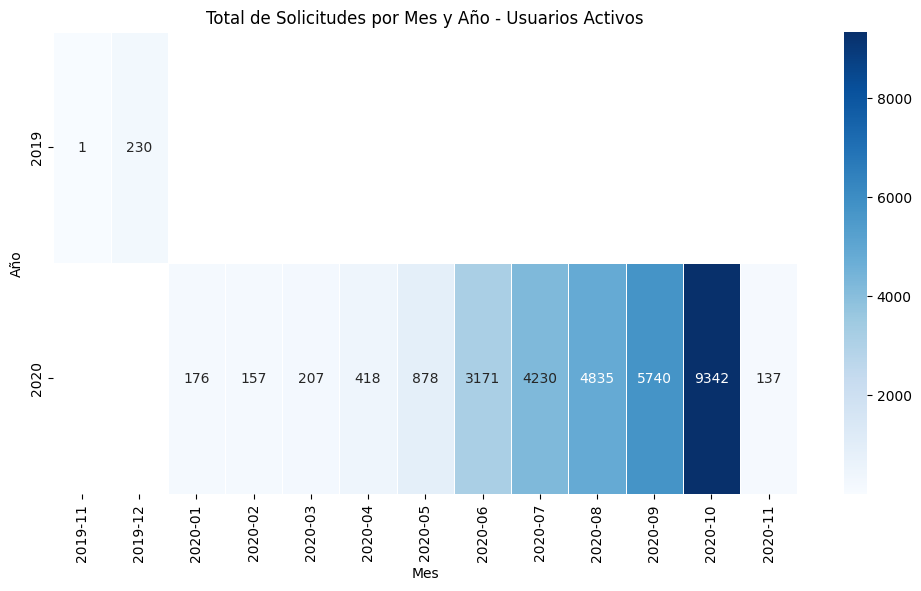

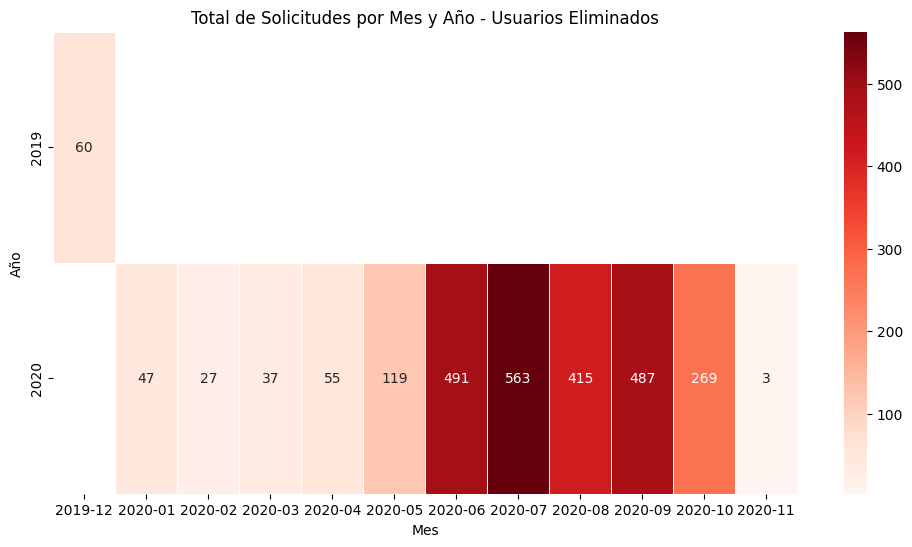

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear una tabla de conteo de solicitudes por mes y año en usuarios activos
solicitudes_por_mes_activos = usuarios_activos.groupby(
    [usuarios_activos["created_at"].dt.year, "mes_solicitud"]
)["user_id"].count().unstack()

# Crear una tabla de conteo de solicitudes por mes y año en usuarios eliminados
solicitudes_por_mes_eliminados = usuarios_eliminados.groupby(
    [usuarios_eliminados["created_at"].dt.year, "mes_solicitud"]
)["deleted_account_id"].count().unstack()

# Matriz de calor para usuarios activos
plt.figure(figsize=(12, 6))
sns.heatmap(solicitudes_por_mes_activos, annot=True, fmt=".0f", cmap="Blues", linewidths=0.5)
plt.title("Total de Solicitudes por Mes y Año - Usuarios Activos")
plt.xlabel("Mes")
plt.ylabel("Año")
plt.show()

# Matriz de calor para usuarios eliminados
plt.figure(figsize=(12, 6))
sns.heatmap(solicitudes_por_mes_eliminados, annot=True, fmt=".0f", cmap="Reds", linewidths=0.5)
plt.title("Total de Solicitudes por Mes y Año - Usuarios Eliminados")
plt.xlabel("Mes")
plt.ylabel("Año")
plt.show()


In [ ]:
# Crear una tabla de conteo de solicitudes canceladas por mes y año en usuarios activos
canceladas_por_mes_activos = usuarios_activos[usuarios_activos["status"] == "cancelled"].groupby(
    [usuarios_activos["created_at"].dt.year, "mes_solicitud"]
)["user_id"].count().unstack()

# Crear una tabla de conteo de solicitudes canceladas por mes y año en usuarios eliminados
canceladas_por_mes_eliminados = usuarios_eliminados[usuarios_eliminados["status"] == "cancelled"].groupby(
    [usuarios_eliminados["created_at"].dt.year, "mes_solicitud"]
)["deleted_account_id"].count().unstack()

# Matriz de calor para solicitudes canceladas en usuarios activos
plt.figure(figsize=(12, 6))
sns.heatmap(canceladas_por_mes_activos, annot=True, fmt=".0f", cmap="Oranges", linewidths=0.5)
plt.title("Total de Solicitudes Canceladas por Mes y Año - Usuarios Activos")
plt.xlabel("Mes")
plt.ylabel("Año")
plt.show()

# Matriz de calor para solicitudes canceladas en usuarios eliminados
plt.figure(figsize=(12, 6))
sns.heatmap(canceladas_por_mes_eliminados, annot=True, fmt=".0f", cmap="Purples", linewidths=0.5)
plt.title("Total de Solicitudes Canceladas por Mes y Año - Usuarios Eliminados")
plt.xlabel("Mes")
plt.ylabel("Año")
plt.show()


ValueError: zero-size array to reduction operation fmin which has no identity

<Figure size 1200x600 with 0 Axes>

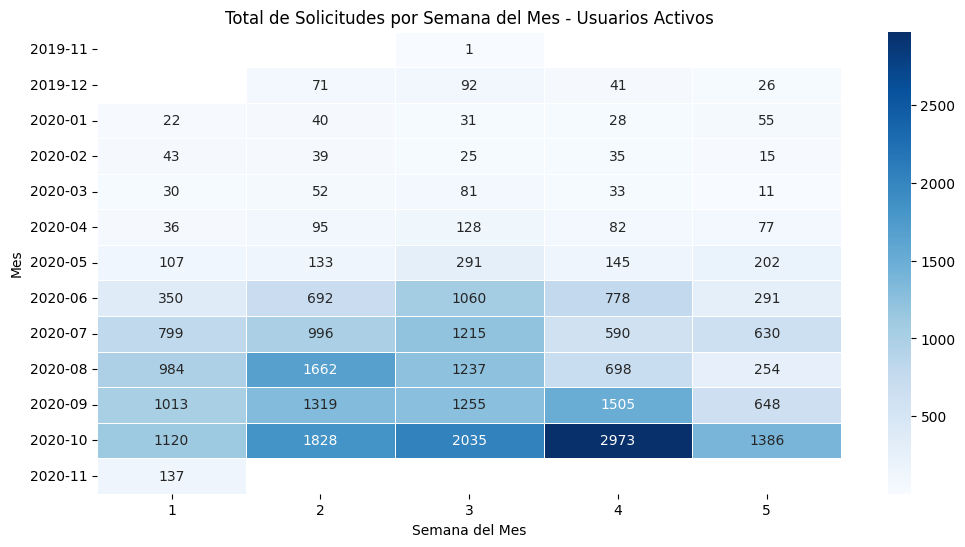

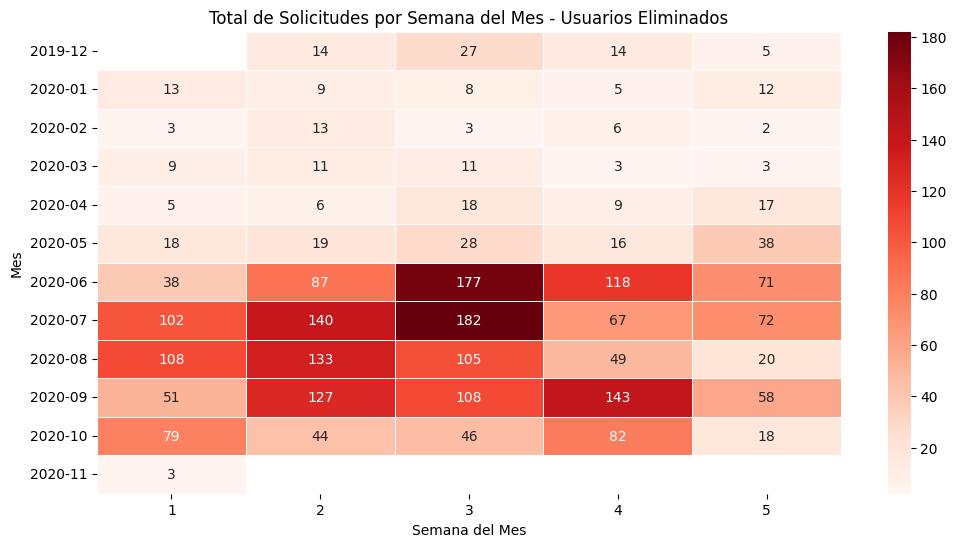

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear una nueva columna con la semana dentro del mes
usuarios_activos["semana_mes_solicitud"] = usuarios_activos["created_at"].dt.day // 7 + 1
usuarios_eliminados["semana_mes_solicitud"] = usuarios_eliminados["created_at"].dt.day // 7 + 1

# Crear una tabla de conteo de solicitudes por mes y semana del mes en usuarios activos
solicitudes_por_semana_mes_activos = usuarios_activos.groupby(
    ["mes_solicitud", "semana_mes_solicitud"]
)["user_id"].count().unstack()

# Crear una tabla de conteo de solicitudes por mes y semana del mes en usuarios eliminados
solicitudes_por_semana_mes_eliminados = usuarios_eliminados.groupby(
    ["mes_solicitud", "semana_mes_solicitud"]
)["deleted_account_id"].count().unstack()

# Crear la matriz de calor para usuarios activos
plt.figure(figsize=(12, 6))
sns.heatmap(solicitudes_por_semana_mes_activos, annot=True, fmt=".0f", cmap="Blues", linewidths=0.5)
plt.title("Total de Solicitudes por Semana del Mes - Usuarios Activos")
plt.xlabel("Semana del Mes")
plt.ylabel("Mes")
plt.show()

# Crear la matriz de calor para usuarios eliminados
plt.figure(figsize=(12, 6))
sns.heatmap(solicitudes_por_semana_mes_eliminados, annot=True, fmt=".0f", cmap="Reds", linewidths=0.5)
plt.title("Total de Solicitudes por Semana del Mes - Usuarios Eliminados")
plt.xlabel("Semana del Mes")
plt.ylabel("Mes")
plt.show()


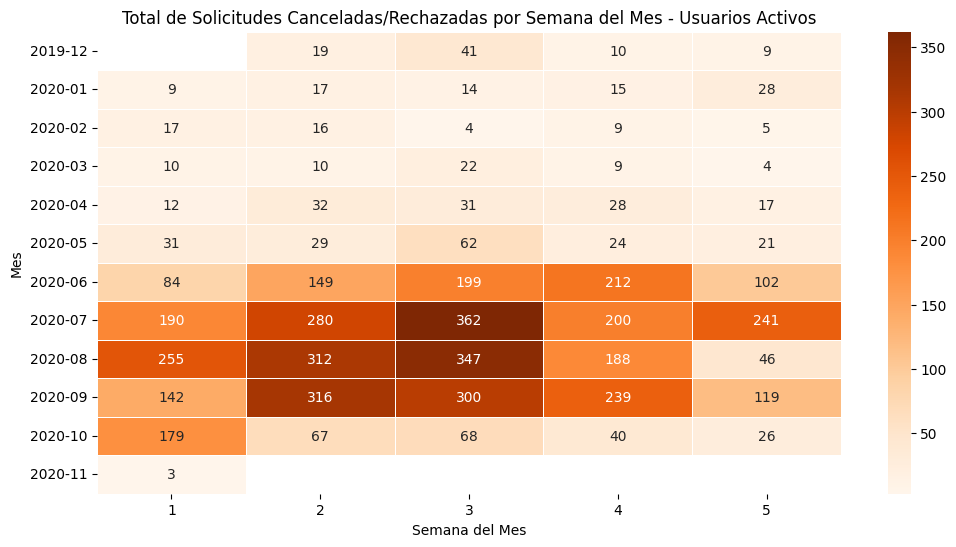

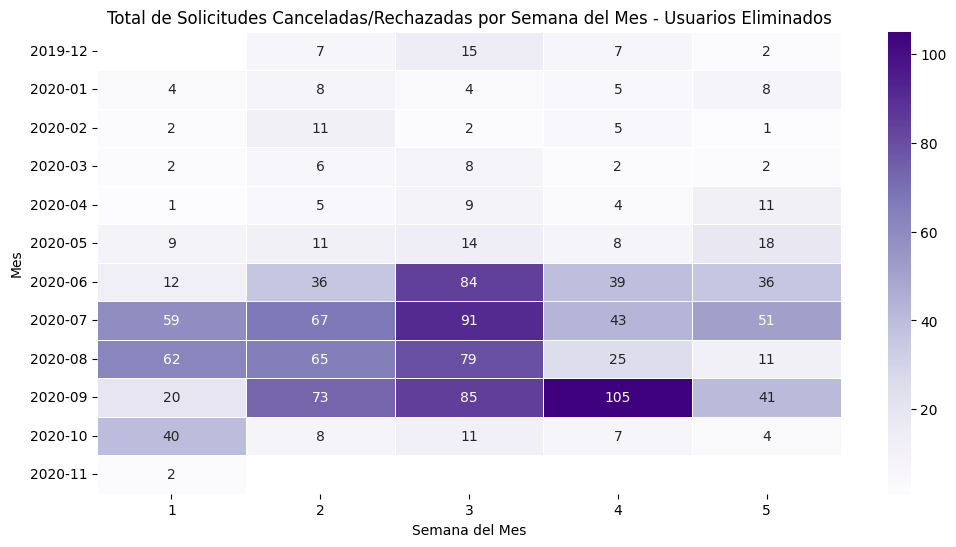

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear una tabla de conteo de solicitudes canceladas/rechazadas por mes y semana del mes en usuarios activos
canceladas_rechazadas_por_semana_mes_activos = usuarios_activos[
    usuarios_activos["status"].isin(["cancelled", "rejected"])
].groupby(["mes_solicitud", "semana_mes_solicitud"])["user_id"].count().unstack()

# Crear una tabla de conteo de solicitudes canceladas/rechazadas por mes y semana del mes en usuarios eliminados
canceladas_rechazadas_por_semana_mes_eliminados = usuarios_eliminados[
    usuarios_eliminados["status"].isin(["cancelled", "rejected"])
].groupby(["mes_solicitud", "semana_mes_solicitud"])["deleted_account_id"].count().unstack()

# Crear la matriz de calor para solicitudes canceladas/rechazadas en usuarios activos
plt.figure(figsize=(12, 6))
sns.heatmap(canceladas_rechazadas_por_semana_mes_activos, annot=True, fmt=".0f", cmap="Oranges", linewidths=0.5)
plt.title("Total de Solicitudes Canceladas/Rechazadas por Semana del Mes - Usuarios Activos")
plt.xlabel("Semana del Mes")
plt.ylabel("Mes")
plt.show()

# Crear la matriz de calor para solicitudes canceladas/rechazadas en usuarios eliminados
plt.figure(figsize=(12, 6))
sns.heatmap(canceladas_rechazadas_por_semana_mes_eliminados, annot=True, fmt=".0f", cmap="Purples", linewidths=0.5)
plt.title("Total de Solicitudes Canceladas/Rechazadas por Semana del Mes - Usuarios Eliminados")
plt.xlabel("Semana del Mes")
plt.ylabel("Mes")
plt.show()


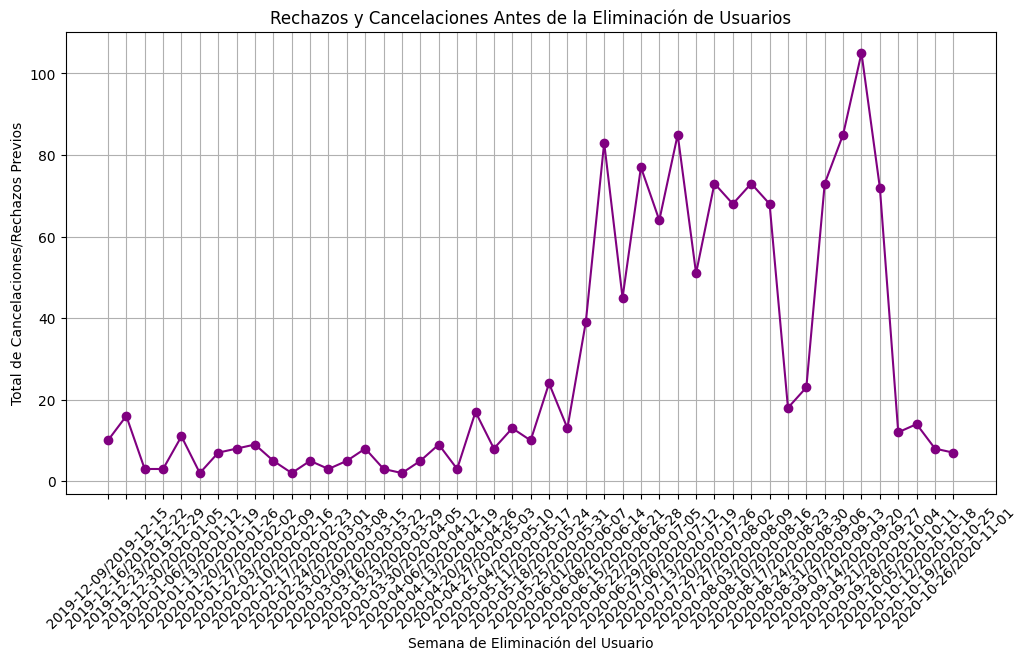

In [ ]:
import matplotlib.pyplot as plt

# Crear una nueva columna con la semana en la que el usuario fue eliminado (para usuarios eliminados)
usuarios_eliminados["semana_eliminacion"] = usuarios_eliminados["created_at"].dt.to_period("W")

# Contar cuántas solicitudes canceladas/rechazadas ocurrieron en las semanas previas a la eliminación
rechazos_previos_eliminacion = usuarios_eliminados[usuarios_eliminados["status"].isin(["cancelled", "rejected"])].groupby(
    ["deleted_account_id", "semana_eliminacion"]
)["deleted_account_id"].count().reset_index(name="rechazos_previos")

# Agrupar por semana de eliminación para ver la tendencia
rechazos_antes_de_eliminar = rechazos_previos_eliminacion.groupby("semana_eliminacion")["rechazos_previos"].sum()

# Graficar la evolución de rechazos antes de la eliminación de usuarios
plt.figure(figsize=(12, 6))
plt.plot(rechazos_antes_de_eliminar.index.astype(str), rechazos_antes_de_eliminar.values, marker="o", linestyle="-", color="purple")
plt.xticks(rotation=45)
plt.xlabel("Semana de Eliminación del Usuario")
plt.ylabel("Total de Cancelaciones/Rechazos Previos")
plt.title("Rechazos y Cancelaciones Antes de la Eliminación de Usuarios")
plt.grid()
plt.show()


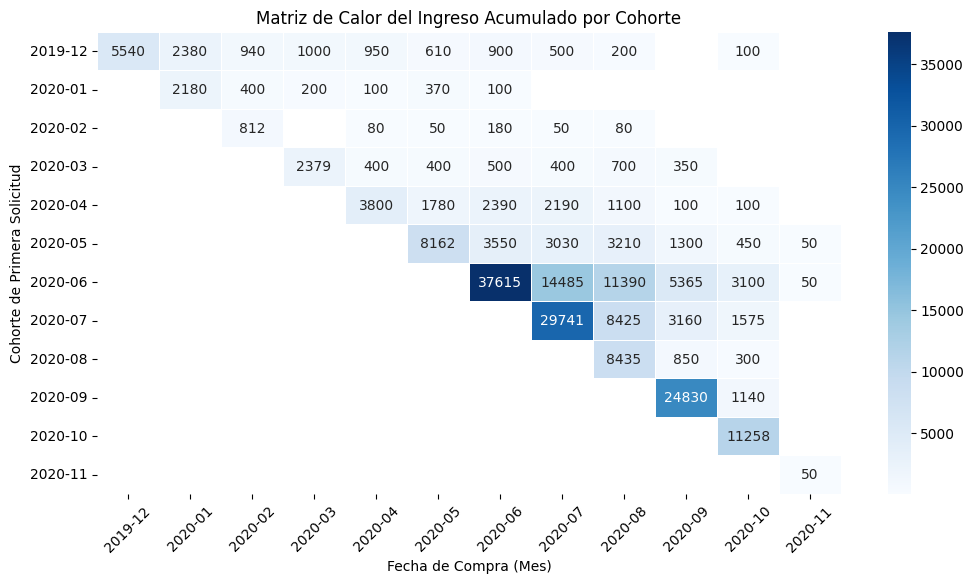

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Crear columna de mes de compra
usuarios_eliminados["Fecha_Compra"] = usuarios_eliminados["created_at"].dt.to_period("M")

# Calcular los ingresos acumulados por cohorte y fecha de compra
usuarios_eliminados["Ingresos_Acumulados"] = usuarios_eliminados.groupby(
    ["cohorte_primer_solicitud", "Fecha_Compra"]
)["amount"].transform("sum")

# Crear tabla pivote con cohortes en filas y meses de compra en columnas
ingresos_heatmap = usuarios_eliminados.pivot_table(
    index="cohorte_primer_solicitud",
    columns="Fecha_Compra",
    values="Ingresos_Acumulados",
    aggfunc="mean"
)

# Visualización con heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(ingresos_heatmap, annot=True, fmt=".0f", cmap="Blues", linewidths=0.5)
plt.title("Matriz de Calor del Ingreso Acumulado por Cohorte")
plt.xlabel("Fecha de Compra (Mes)")
plt.ylabel("Cohorte de Primera Solicitud")
plt.xticks(rotation=45)
plt.show()


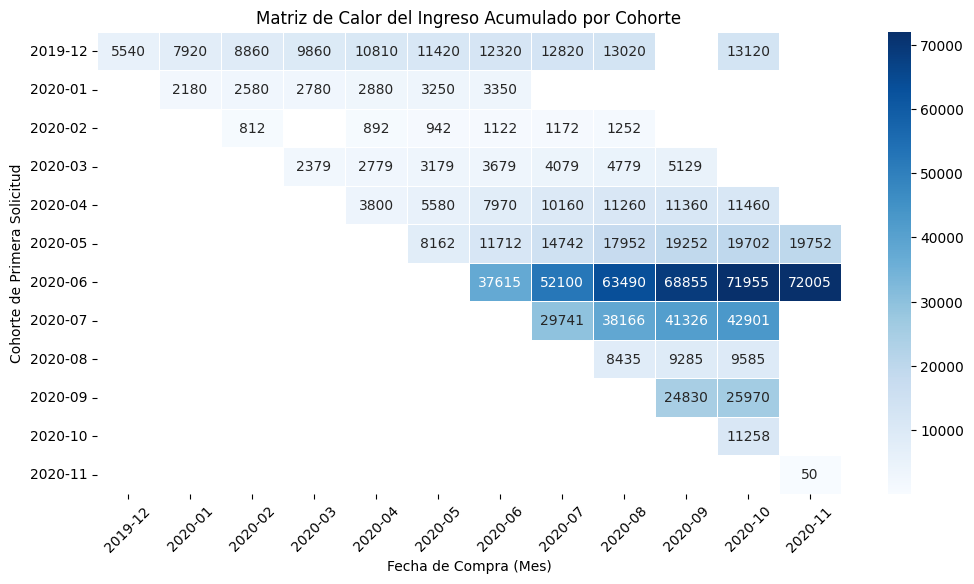

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Asegurar que las fechas están en formato datetime
usuarios_eliminados["created_at"] = pd.to_datetime(usuarios_eliminados["created_at"], errors="coerce")

# Calcular los ingresos acumulados correctamente usando cumsum()
ingresos_acumulados = usuarios_eliminados.groupby(["cohorte_primer_solicitud", "mes_solicitud"])["amount"].sum().groupby(level=0).cumsum()

# Crear tabla pivote con cohortes en filas y meses de compra en columnas (sin llenar valores NaN con 0)
ingresos_heatmap = ingresos_acumulados.unstack()

# Visualización con heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(ingresos_heatmap, annot=True, fmt=".0f", cmap="Blues", linewidths=0.5, mask=ingresos_heatmap.isna())
plt.title("Matriz de Calor del Ingreso Acumulado por Cohorte")
plt.xlabel("Fecha de Compra (Mes)")
plt.ylabel("Cohorte de Primera Solicitud")
plt.xticks(rotation=45)
plt.show()


,2019-12
mes_solicitud,
2019-12,5540.0
2020-01,7920.0
2020-02,8860.0
2020-03,9860.0
2020-04,10810.0
2020-05,11420.0
2020-06,12320.0
2020-07,12820.0
2020-08,13020.0


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but PolynomialFeatures was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but PolynomialFeatures was fitted without feature names
  warnings.warn(


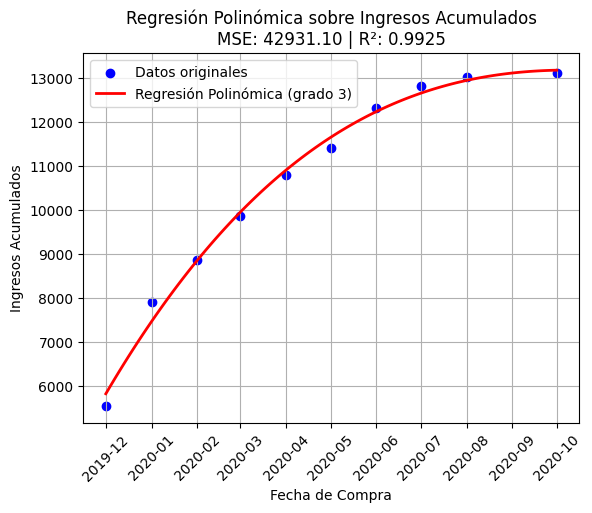

In [21]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

fila_2019_12 = ingresos_heatmap.loc["2019-12"]

df_no_nulos = fila_2019_12.dropna()

# Convertir la Serie en un DataFrame
df_no_nulos = df_no_nulos.to_frame().reset_index()

# Renombrar columnas si es necesario
df_no_nulos.columns = ["Fecha_Compra", "Ingresos_Acumulados"]

# Asegurar que ambas listas están estructuradas como columnas de un DataFrame sin valores desalineados
df_no_nulos = df_no_nulos.dropna().reset_index(drop=True)

df_no_nulos["Fecha_Compra"] = pd.to_datetime(df_no_nulos["Fecha_Compra"])

df_no_nulos["Mes_Num"] = (df_no_nulos["Fecha_Compra"] - df_no_nulos["Fecha_Compra"].min()).dt.days // 30

X = df_no_nulos[["Mes_Num"]].values  # Variable independiente (meses)
y = df_no_nulos["Ingresos_Acumulados"].values  # Variable dependiente (ingresos acumulados)

# Transformar las características para regresión polinómica de grado 3
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)


# Generar predicciones en el rango de datos
X_pred = np.linspace(df_no_nulos["Mes_Num"].min(), df_no_nulos["Mes_Num"].max(), 100).reshape(-1, 1)

# Transformar los valores para la regresión polinómica
X_pred_poly = poly.transform(X_pred)

# Hacer predicciones con el modelo entrenado
y_pred = model.predict(X_pred_poly)

# Calcular el Error Cuadrático Medio (MSE)
mse = mean_squared_error(df_no_nulos["Ingresos_Acumulados"], model.predict(poly.transform(df_no_nulos[["Mes_Num"]])))

# Calcular el coeficiente de determinación R²
r2 = r2_score(df_no_nulos["Ingresos_Acumulados"], model.predict(poly.transform(df_no_nulos[["Mes_Num"]])))

# Convertir los valores de predicción a fechas reales usando interpolación
fechas_pred = pd.date_range(start=df_no_nulos["Fecha_Compra"].min(),
                            end=df_no_nulos["Fecha_Compra"].max(),
                            periods=100)

# Graficar los datos originales
plt.scatter(df_no_nulos["Fecha_Compra"], df_no_nulos["Ingresos_Acumulados"], color='blue', label="Datos originales")

# Graficar la curva de la regresión polinómica
plt.plot(fechas_pred, y_pred, color='red', linestyle='-', linewidth=2, label="Regresión Polinómica (grado 3)")

# Configurar la gráfica con el MSE y R²
plt.xlabel("Fecha de Compra")
plt.ylabel("Ingresos Acumulados")
plt.title(f"Regresión Polinómica sobre Ingresos Acumulados\nMSE: {mse:.2f} | R²: {r2:.4f}")
plt.xticks(rotation=45)  # Rotar las fechas en el eje X para mejor visualización
plt.legend()
plt.grid(True)
plt.show()



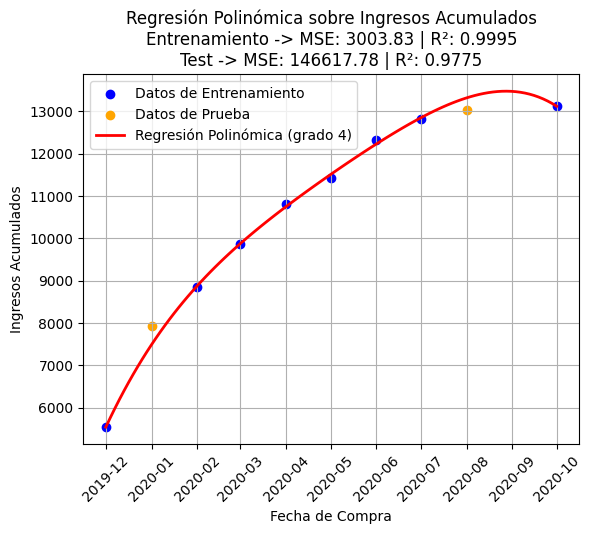

In [19]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score

# Filtrar datos de diciembre de 2019
fila_2019_12 = ingresos_heatmap.loc["2019-12"]

# Eliminar valores nulos
df_no_nulos = fila_2019_12.dropna().to_frame().reset_index()
df_no_nulos.columns = ["Fecha_Compra", "Ingresos_Acumulados"]
df_no_nulos["Fecha_Compra"] = pd.to_datetime(df_no_nulos["Fecha_Compra"])
df_no_nulos["Mes_Num"] = (df_no_nulos["Fecha_Compra"] - df_no_nulos["Fecha_Compra"].min()).dt.days // 30

# Definir variables
X = df_no_nulos[["Mes_Num"]].values  # Variable independiente (meses)
y = df_no_nulos["Ingresos_Acumulados"].values  # Variable dependiente (ingresos acumulados)

# División de datos en 80% entrenamiento y 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Transformación para regresión polinómica de grado 4
poly = PolynomialFeatures(degree=4)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Entrenar modelo
model = LinearRegression()
model.fit(X_train_poly, y_train)

# Predicciones en datos de prueba
y_test_pred = model.predict(X_test_poly)

# Generar predicciones en un rango continuo de datos
X_pred = np.linspace(df_no_nulos["Mes_Num"].min(), df_no_nulos["Mes_Num"].max(), 100).reshape(-1, 1)
X_pred_poly = poly.transform(X_pred)
y_pred = model.predict(X_pred_poly)

# Calcular métricas
mse_train = mean_squared_error(y_train, model.predict(X_train_poly))
r2_train = r2_score(y_train, model.predict(X_train_poly))

mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

# Convertir fechas para predicción
fechas_pred = pd.date_range(start=df_no_nulos["Fecha_Compra"].min(),
                            end=df_no_nulos["Fecha_Compra"].max(),
                            periods=100)

# **Corrección del mapeo de fechas para entrenamiento y prueba**
df_train = pd.DataFrame({"Mes_Num": X_train.flatten(), "Ingresos_Acumulados": y_train})
df_test = pd.DataFrame({"Mes_Num": X_test.flatten(), "Ingresos_Acumulados": y_test})

# Asignar fechas reales a cada conjunto usando merge
df_train = df_train.merge(df_no_nulos[["Mes_Num", "Fecha_Compra"]], on="Mes_Num", how="left")
df_test = df_test.merge(df_no_nulos[["Mes_Num", "Fecha_Compra"]], on="Mes_Num", how="left")

# Graficar datos originales diferenciando entre entrenamiento y prueba
plt.scatter(df_train["Fecha_Compra"], df_train["Ingresos_Acumulados"], color='blue', label="Datos de Entrenamiento")
plt.scatter(df_test["Fecha_Compra"], df_test["Ingresos_Acumulados"], color='orange', label="Datos de Prueba")

# Graficar la curva de la regresión polinómica
plt.plot(fechas_pred, y_pred, color='red', linestyle='-', linewidth=2, label="Regresión Polinómica (grado 4)")

# Configurar la gráfica con el MSE y R²
plt.xlabel("Fecha de Compra")
plt.ylabel("Ingresos Acumulados")
plt.title(f"Regresión Polinómica sobre Ingresos Acumulados\n"
          f"Entrenamiento -> MSE: {mse_train:.2f} | R²: {r2_train:.4f}\n"
          f"Test -> MSE: {mse_test:.2f} | R²: {r2_test:.4f}")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


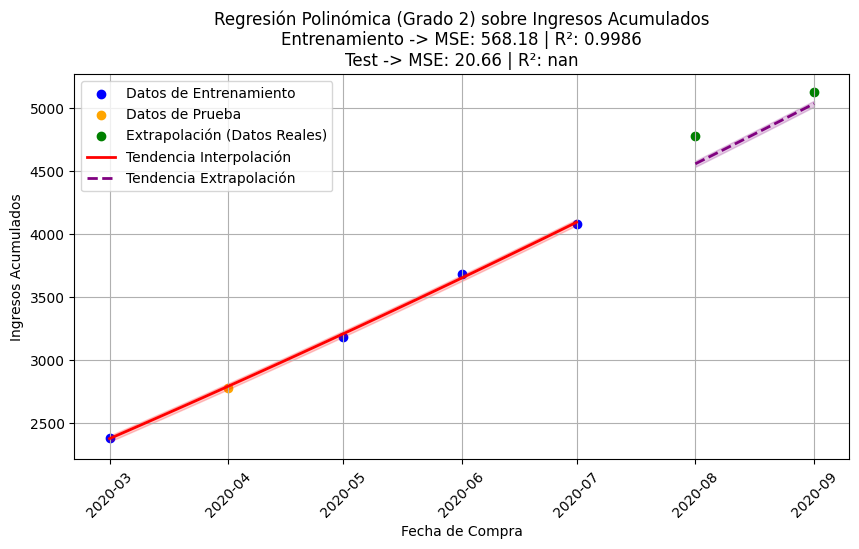

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


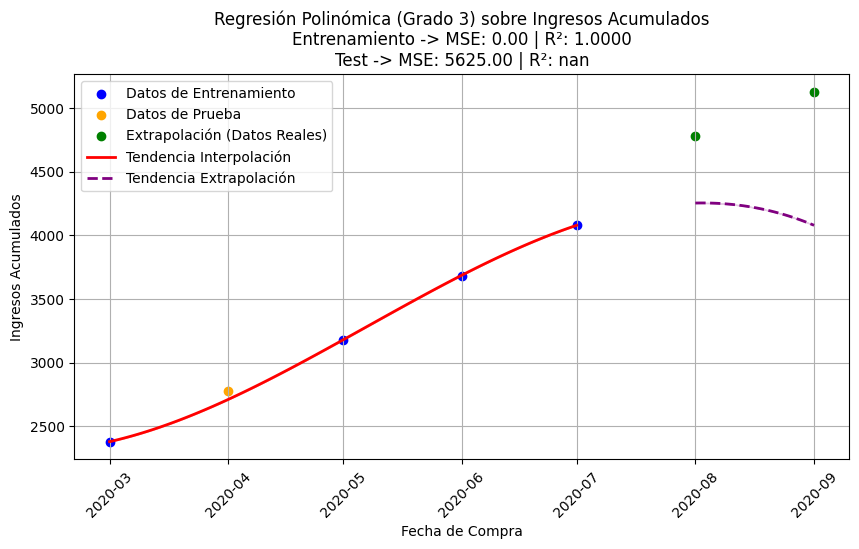

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


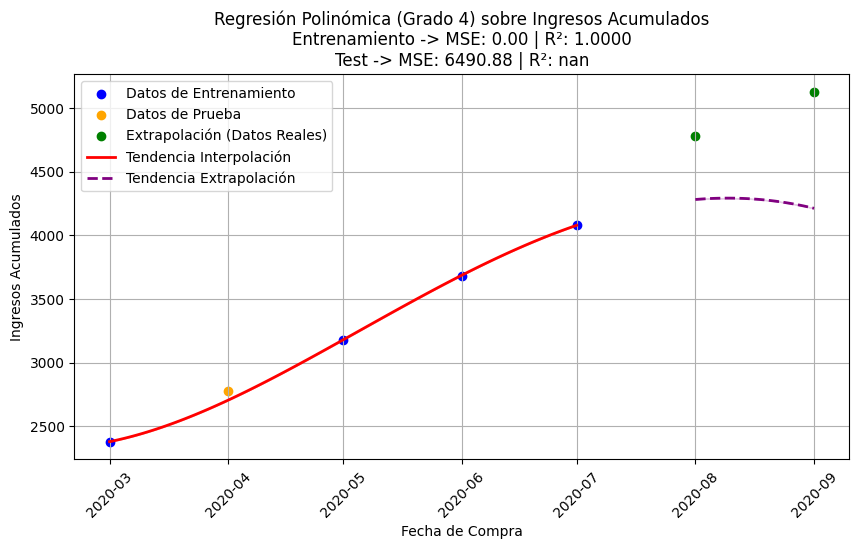

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


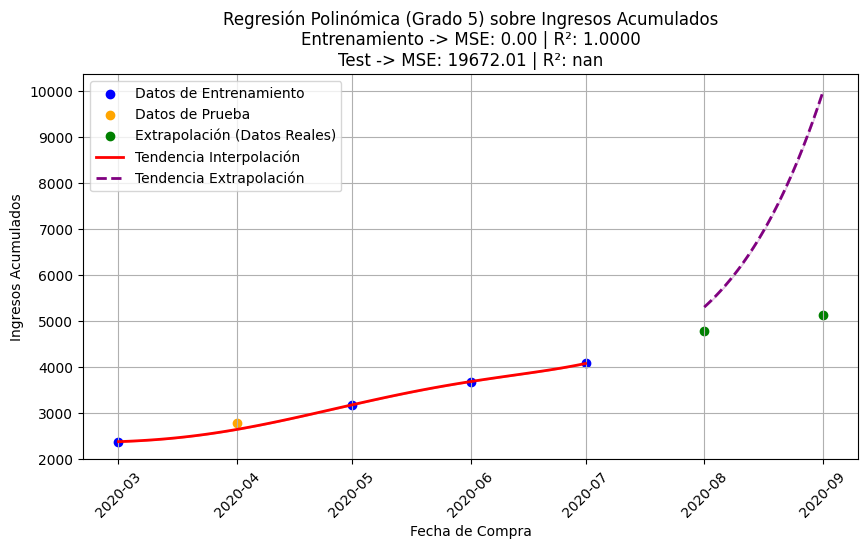

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


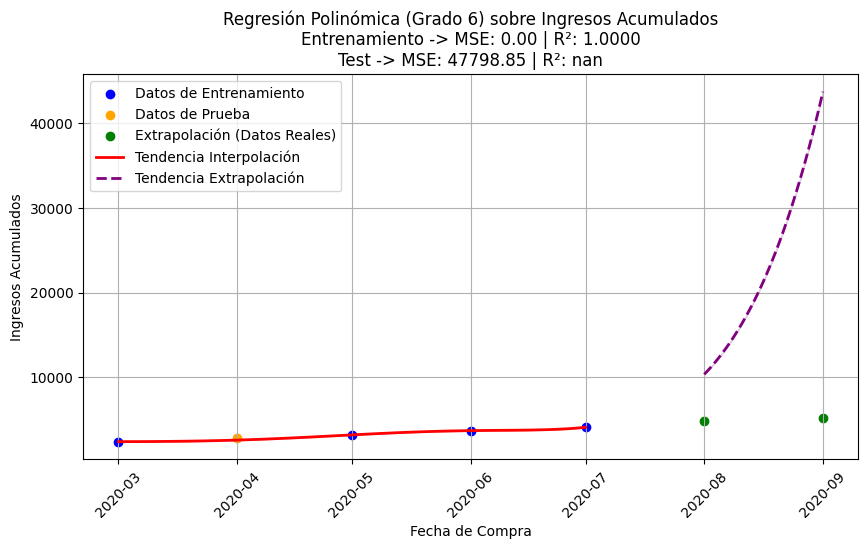

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


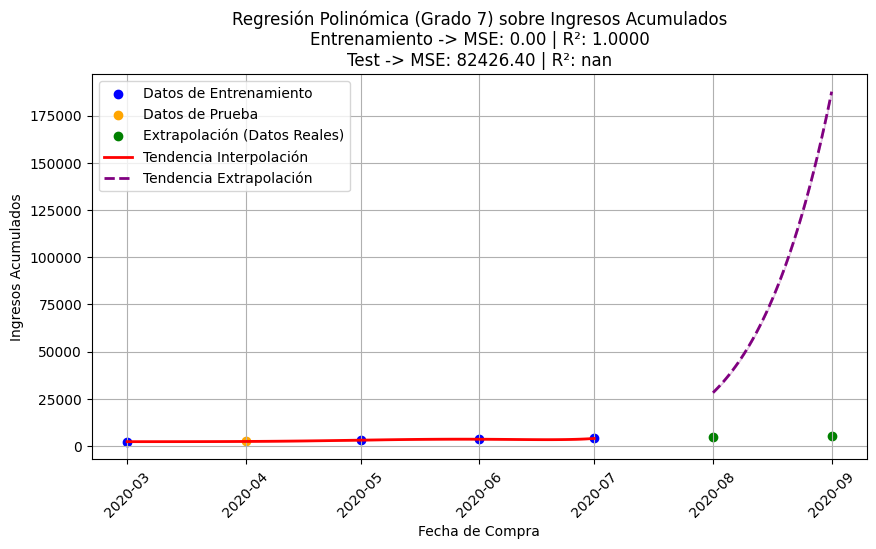

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


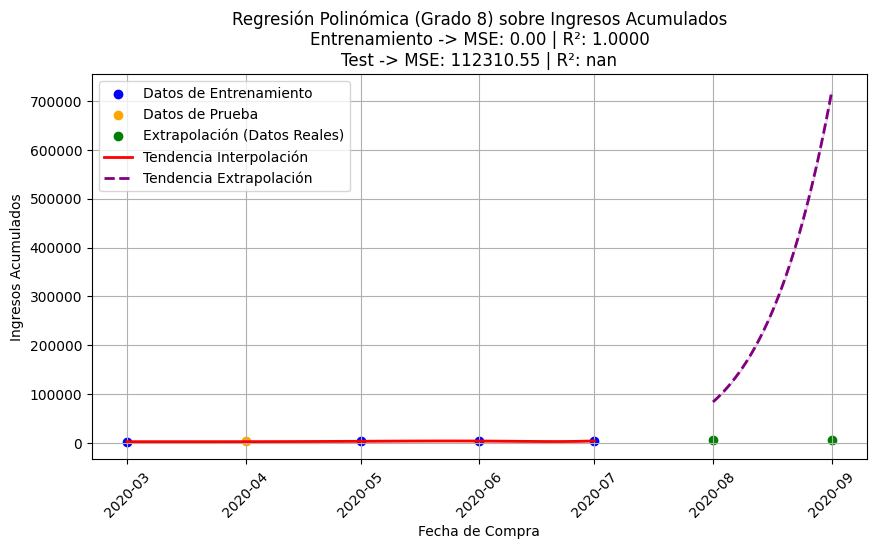

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


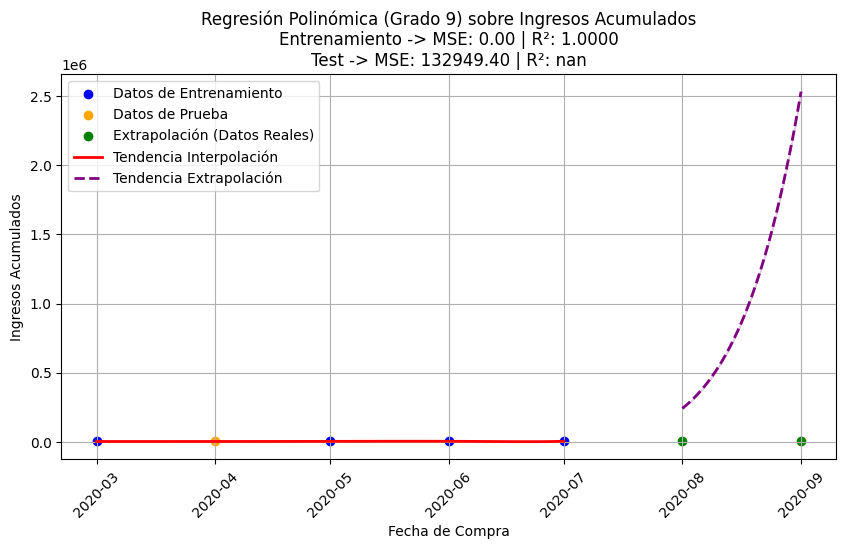

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


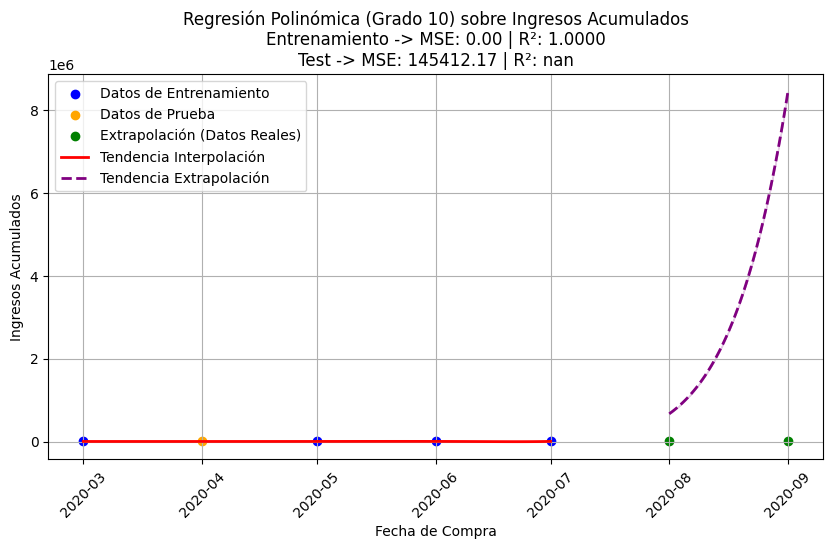

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


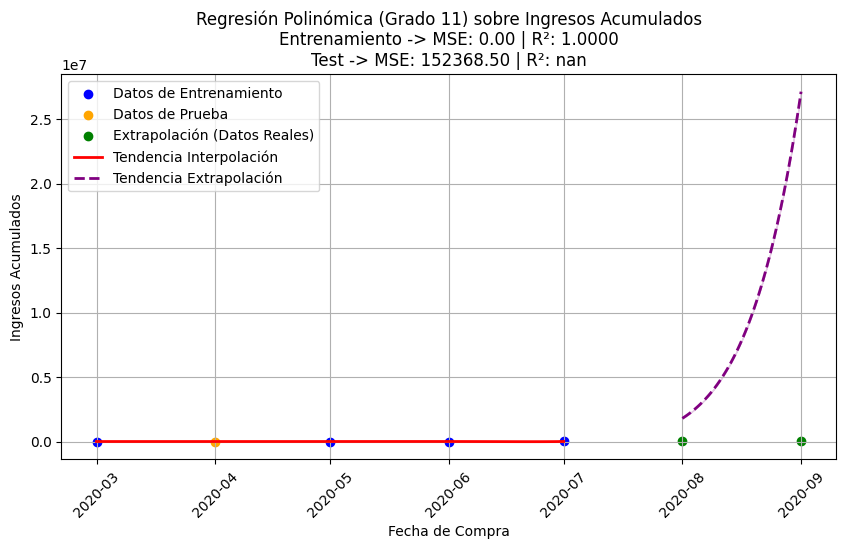

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


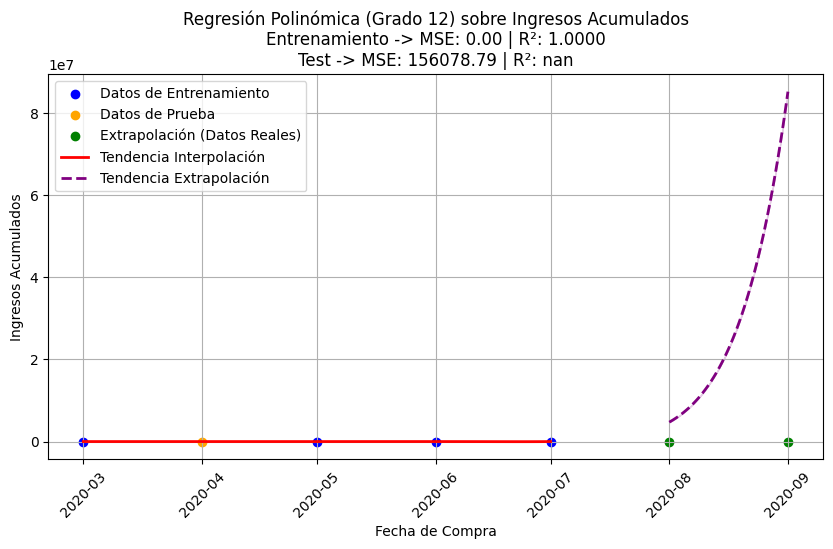

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


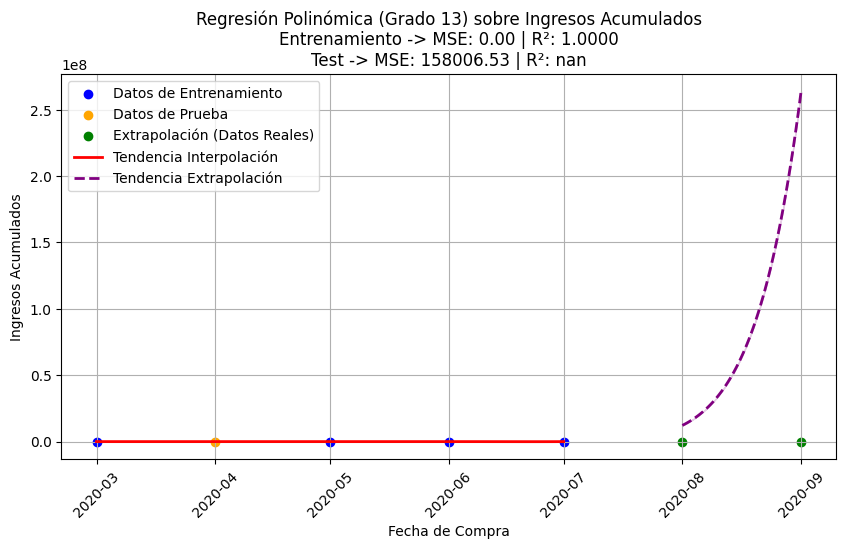

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


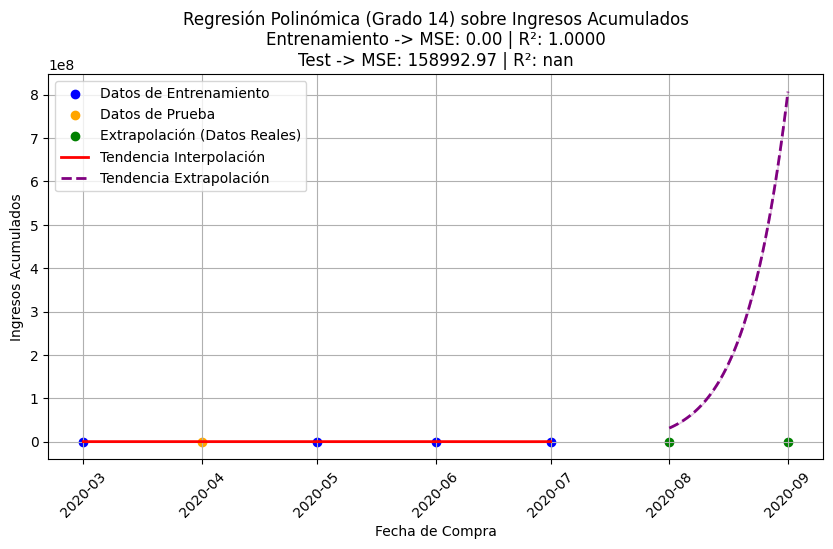

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


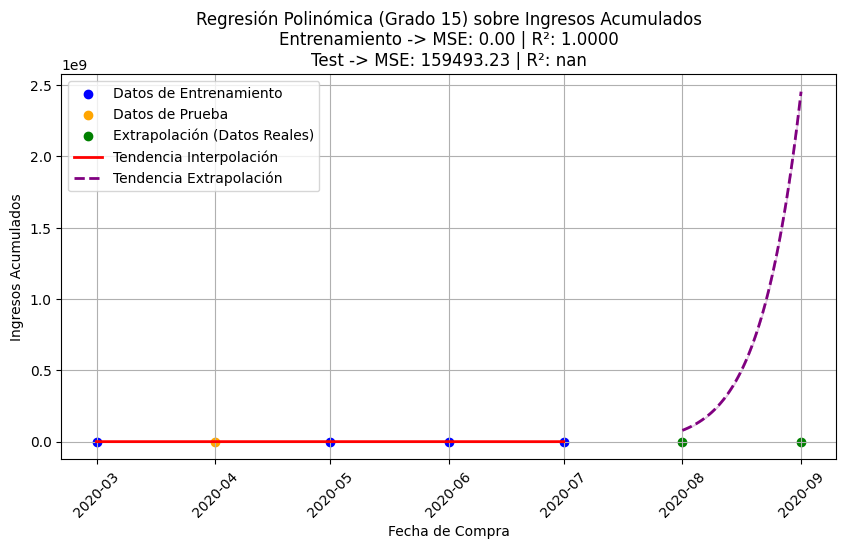

In [18]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score

# Dividir los datos totales en 80% interpolación y 20% extrapolación (sin que el modelo vea los datos de extrapolación)
n_total = len(df_no_nulos)
n_interpolacion = int(n_total * 0.8)

# Datos de interpolación y extrapolación
df_interpolacion = df_no_nulos.iloc[:n_interpolacion].copy()
df_extrapolacion = df_no_nulos.iloc[n_interpolacion:].copy()

# Definir variables para interpolación
X_interpolacion = df_interpolacion[["Mes_Num"]].values
y_interpolacion = df_interpolacion["Ingresos_Acumulados"].values

# Dividir interpolación en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_interpolacion, y_interpolacion, df_interpolacion.index, test_size=0.2, random_state=42
)

# Crear DataFrames con los datos originales para conservar las fechas
df_train = df_interpolacion.loc[idx_train].copy()
df_test = df_interpolacion.loc[idx_test].copy()

# Función para entrenar y evaluar un modelo polinómico
def entrenar_modelo_polinomico(grado):
    poly = PolynomialFeatures(degree=grado)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_test_pred = model.predict(X_test_poly)

    # Predicción de interpolación y extrapolación
    X_pred_interpolacion = np.linspace(df_interpolacion["Mes_Num"].min(), df_interpolacion["Mes_Num"].max(), 100).reshape(-1, 1)
    X_pred_interpolacion_poly = poly.transform(X_pred_interpolacion)
    y_pred_interpolacion = model.predict(X_pred_interpolacion_poly)

    X_pred_extrapolacion = np.linspace(df_extrapolacion["Mes_Num"].min(), df_extrapolacion["Mes_Num"].max(), 100).reshape(-1, 1)
    X_pred_extrapolacion_poly = poly.transform(X_pred_extrapolacion)
    y_pred_extrapolacion = model.predict(X_pred_extrapolacion_poly)

    # Calcular métricas
    mse_train = mean_squared_error(y_train, model.predict(X_train_poly))
    r2_train = r2_score(y_train, model.predict(X_train_poly))

    mse_test = mean_squared_error(y_test, y_test_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # Calcular desviación estándar de los residuos
    residuos = y_train - model.predict(X_train_poly)
    std_residuos = np.std(residuos)

    # Convertir fechas para predicción
    fechas_pred_interpolacion = pd.date_range(start=df_interpolacion["Fecha_Compra"].min(),
                                              end=df_interpolacion["Fecha_Compra"].max(),
                                              periods=100)

    fechas_pred_extrapolacion = pd.date_range(start=df_extrapolacion["Fecha_Compra"].min(),
                                              end=df_extrapolacion["Fecha_Compra"].max(),
                                              periods=100)

    # Graficar resultados
    plt.figure(figsize=(10, 5))
    plt.scatter(df_train["Fecha_Compra"], df_train["Ingresos_Acumulados"], color='blue', label="Datos de Entrenamiento")
    plt.scatter(df_test["Fecha_Compra"], df_test["Ingresos_Acumulados"], color='orange', label="Datos de Prueba")
    plt.scatter(df_extrapolacion["Fecha_Compra"], df_extrapolacion["Ingresos_Acumulados"], color='green', label="Extrapolación (Datos Reales)")

    plt.plot(fechas_pred_interpolacion, y_pred_interpolacion, color='red', linestyle='-', linewidth=2, label="Tendencia Interpolación")
    plt.plot(fechas_pred_extrapolacion, y_pred_extrapolacion, color='purple', linestyle='--', linewidth=2, label="Tendencia Extrapolación")

    # Agregar área de incertidumbre con std_residuos
    plt.fill_between(fechas_pred_interpolacion,
                     y_pred_interpolacion.flatten() - std_residuos,
                     y_pred_interpolacion.flatten() + std_residuos,
                     color='red', alpha=0.2)
    plt.fill_between(fechas_pred_extrapolacion,
                     y_pred_extrapolacion.flatten() - std_residuos,
                     y_pred_extrapolacion.flatten() + std_residuos,
                     color='purple', alpha=0.2)

    plt.xlabel("Fecha de Compra")
    plt.ylabel("Ingresos Acumulados")
    plt.title(f"Regresión Polinómica (Grado {grado}) sobre Ingresos Acumulados\n"
              f"Entrenamiento -> MSE: {mse_train:.2f} | R²: {r2_train:.4f}\n"
              f"Test -> MSE: {mse_test:.2f} | R²: {r2_test:.4f}")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.show()

# Probar el modelo con diferentes grados del polinomio (2 a 15)
for grado in range(2, 16):
    entrenar_modelo_polinomico(grado)


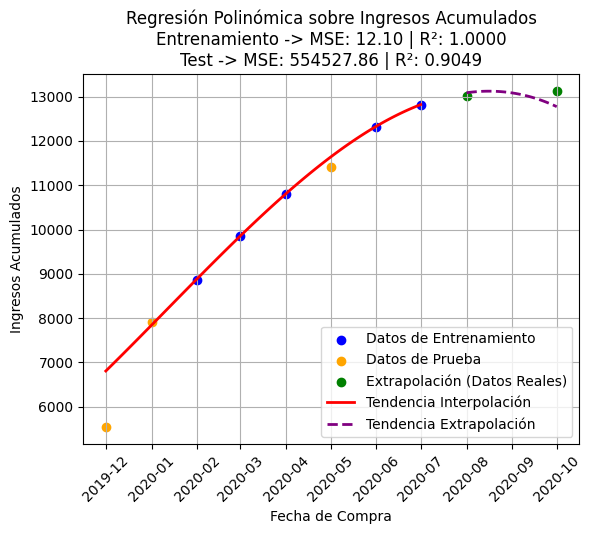

In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score

# Dividir los datos totales en 80% interpolación y 20% extrapolación (sin que el modelo vea los datos de extrapolación)
n_total = len(df_no_nulos)
n_interpolacion = int(n_total * 0.8)

# Datos de interpolación y extrapolación
df_interpolacion = df_no_nulos.iloc[:n_interpolacion].copy()
df_extrapolacion = df_no_nulos.iloc[n_interpolacion:].copy()

# Definir variables para interpolación
X_interpolacion = df_interpolacion[["Mes_Num"]].values
y_interpolacion = df_interpolacion["Ingresos_Acumulados"].values

# Dividir interpolación en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_interpolacion, y_interpolacion, df_interpolacion.index, test_size=0.3, random_state=42
)

# Crear DataFrames con los datos originales para conservar las fechas
df_train = df_interpolacion.loc[idx_train].copy()
df_test = df_interpolacion.loc[idx_test].copy()

# Transformación para regresión polinómica de grado 4 para interpolación
poly_interpolacion = PolynomialFeatures(degree=3)
X_train_poly = poly_interpolacion.fit_transform(X_train)
X_test_poly = poly_interpolacion.transform(X_test)

# Entrenar modelo para interpolación
model_interpolacion = LinearRegression()
model_interpolacion.fit(X_train_poly, y_train)

# Predicciones en datos de prueba de interpolación
y_test_pred = model_interpolacion.predict(X_test_poly)

# Generar predicciones en un rango continuo de datos para interpolación
X_pred_interpolacion = np.linspace(df_interpolacion["Mes_Num"].min(), df_interpolacion["Mes_Num"].max(), 100).reshape(-1, 1)
X_pred_interpolacion_poly = poly_interpolacion.transform(X_pred_interpolacion)
y_pred_interpolacion = model_interpolacion.predict(X_pred_interpolacion_poly)

# **Predicción de extrapolación sin entrenar con los datos de extrapolación**
X_pred_extrapolacion = np.linspace(df_extrapolacion["Mes_Num"].min(), df_extrapolacion["Mes_Num"].max(), 100).reshape(-1, 1)
X_pred_extrapolacion_poly = poly_interpolacion.transform(X_pred_extrapolacion)  # Se usa el modelo de interpolación

y_pred_extrapolacion = model_interpolacion.predict(X_pred_extrapolacion_poly)

# Calcular métricas
mse_train = mean_squared_error(y_train, model_interpolacion.predict(X_train_poly))
r2_train = r2_score(y_train, model_interpolacion.predict(X_train_poly))

mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

# Convertir fechas para predicción
fechas_pred_interpolacion = pd.date_range(start=df_interpolacion["Fecha_Compra"].min(),
                                          end=df_interpolacion["Fecha_Compra"].max(),
                                          periods=100)

fechas_pred_extrapolacion = pd.date_range(start=df_extrapolacion["Fecha_Compra"].min(),
                                          end=df_extrapolacion["Fecha_Compra"].max(),
                                          periods=100)

# Graficar datos originales diferenciando entre entrenamiento, prueba y extrapolación
plt.scatter(df_train["Fecha_Compra"], df_train["Ingresos_Acumulados"], color='blue', label="Datos de Entrenamiento")
plt.scatter(df_test["Fecha_Compra"], df_test["Ingresos_Acumulados"], color='orange', label="Datos de Prueba")
plt.scatter(df_extrapolacion["Fecha_Compra"], df_extrapolacion["Ingresos_Acumulados"], color='green', label="Extrapolación (Datos Reales)")

# Graficar la curva de la regresión polinómica
plt.plot(fechas_pred_interpolacion, y_pred_interpolacion, color='red', linestyle='-', linewidth=2, label="Tendencia Interpolación")
plt.plot(fechas_pred_extrapolacion, y_pred_extrapolacion, color='purple', linestyle='--', linewidth=2, label="Tendencia Extrapolación")

# Configurar la gráfica con métricas
plt.xlabel("Fecha de Compra")
plt.ylabel("Ingresos Acumulados")
plt.title(f"Regresión Polinómica sobre Ingresos Acumulados\n"
          f"Entrenamiento -> MSE: {mse_train:.2f} | R²: {r2_train:.4f}\n"
          f"Test -> MSE: {mse_test:.2f} | R²: {r2_test:.4f}")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()
